In [3]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import mesa

from mesa.visualization import SolaraViz, make_plot_component, make_space_component

In [ ]:
print(f"Mesa version: {mesa.__version__}")



def update_expectation(expected_outcome, outcome, alpha):
    expected_outcome += alpha * (outcome - expected_outcome)
    return expected_outcome
"""This function enacts the Rescorla-Wagner rule, where with every step the agent can
reinforce their position on whether to use AI or not in the next step"""


boost = 0.10
middle = 0.10
scaler = 0.02
expected = 0.5
alpha = 0.1
beta = 0.05

class AdoptionAgent(mesa.Agent):
    """An agent with skill, and the ability to choose to use artificial intelligence tools,
    that can compete to complete a task if it meets another agent"""

    def __init__(self, model):
        """initialize an AdoptionAgent instance.

        Args:
            model: A model instance

            self.skill: Is a normally distributed set skill level between 0 and 1 that can increase by
            succesfully winning at tasks without using AI or decrease by using AI

            self.ability: Is a combination of skill, luck and AI usage between 0 and 1 that
            is the metric used to see who wins in a 'compete' instance.

            self.wins: Is a value that counts the amount of times the chosen agent won.

            self.losses: Counts the losses.

            self.aichoice: Is the outcome of their decision to either use or not use AI, either a 0 or a 1 respectively.

            self.expected: Is the leaning of an agent towards using or not using AI.

            self.evidence: Is the outcome of the competition that suggests if using AI was useful or not.
            If they won without using AI evidence will be set to 0, if they lost and used AI it will also be set to 0.
            If they lost simply then it will be set to 1 and if they won using AI it will also be set to 1.
            This value sets the direction for the update_expectation function.
        """
        super().__init__(model)
        self.skill = np.clip(np.random.normal(loc=0.5, scale=0.2), 0, 1)
        self.ability = 0
        self.wins = 1
        self.losses = 1
        self.aichoice = 0
        self.expected = expected
        self.evidence = 0
        self.luck = 0
        self.alpha = alpha

    def move(self):
        """Move agent to a random neighboring cell."""
        possible_steps = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=False
        )
        new_position = self.random.choice(possible_steps)
        self.model.grid.move_agent(self, new_position)

    def compete(self):
        """One agent picks another agent randomly and compares its ability scores to it updating all of its own info
        In this version of compete it is possible that both agents win or both agents lose as the luck value will
        vary between each agents' compete step."""
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        if len(cellmates) > 1:
            other = self.random.choice(cellmates)

            
            self.aichoice = np.random.choice([0, 1], p=[1 - self.expected, self.expected])

        
            other.aichoice = np.random.choice([0, 1], p=[1 - other.expected, other.expected])

            self.luck = np.clip(np.random.normal(loc= middle , scale= scaler ), 0, 1)
            other.luck = np.clip(np.random.normal(loc= middle , scale= scaler ), 0, 1)

            self.ability = self.skill + self.aichoice * boost + self.luck
            other.ability = other.skill + other.aichoice * boost + other.luck
            self.skill = np.clip(self.skill + ((-1)**self.aichoice ) * beta, 0, 1)
            if self.ability > other.ability:
                self.wins += 1
                self.evidence = 1 * self.aichoice
                self.expected = update_expectation(self.expected, self.evidence, alpha)

            else:
                self.losses += 1
                self.evidence = 1 - self.aichoice
                self.expected = update_expectation(self.expected, self.evidence, alpha)




    def step(self):
        """do one step of the agent."""
        self.move()
        self.compete()


class AdoptionModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=10, width=10, height=10, seed=None):
        """Initialize a competition instance.

        Args:
            N: The number of agents.
            width: width of the grid.
            height: Height of the grid.
        """
        super().__init__(seed=seed)
        self.num_agents = n
        self.grid = mesa.space.MultiGrid(width, height, True)

        # Create agents
        agents = AdoptionAgent.create_agents(model=self, n=n)
        # Create x and y positions for agents
        x = self.rng.integers(0, self.grid.width, size=(n,))
        y = self.rng.integers(0, self.grid.height, size=(n,))
        for a, i, j in zip(agents, x, y):
            # Add the agent to a random grid cell
            self.grid.place_agent(a, (i, j))

        self.datacollector = mesa.DataCollector(
            agent_reporters={
                "Skill": "skill",
                "Ability": "ability",
                "Wins": "wins",
                "Losses": "losses",
                "AI Usage Choice": "aichoice",
                "Expected": "expected",
                "Outcome": "outcome",
                "Luck" : "luck"
            }
        )
        self.datacollector.collect(self)

    def step(self):
        """do one step of the model"""
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)


Mesa version: 3.1.5


In [5]:
model = AdoptionModel(100)
for _ in range(200):
    model.step()


data = model.datacollector.get_agent_vars_dataframe()
# Use seaborn

data

Skill   Ability  Wins  Losses  AI Usage Choice  Expected  \
Step AgentID                                                                
0    1        0.400119  0.000000     1       1                0  0.500000   
     2        0.325642  0.000000     1       1                0  0.500000   
     3        0.054413  0.000000     1       1                0  0.500000   
     4        0.369050  0.000000     1       1                0  0.500000   
     5        0.099410  0.000000     1       1                0  0.500000   
...                ...       ...   ...     ...              ...       ...   
200  96       0.433099  0.614603    47      82                1  0.473734   
     97       0.050000  0.092564    35      99                0  0.505045   
     98       0.100000  0.347391    34      95                1  0.496603   
     99       0.150000  0.352685    20      98                1  0.570727   
     100      0.672872  0.908197    52      72                1  0.470954   

              Outcome      Luck  
Step AgentID                     
0    1              0  0.000000  
     2              0  0.000000  
     3              0  0.000000  
     4              0  0.000000  
     5              0  0.000000  
...               ...       ...  
200  96             0  0.081505  
     97             1  0.092564  
     98             1  0.097391  
     99             1  0.102685  
     100            0  0.085325  

[20100 rows x 8 columns]

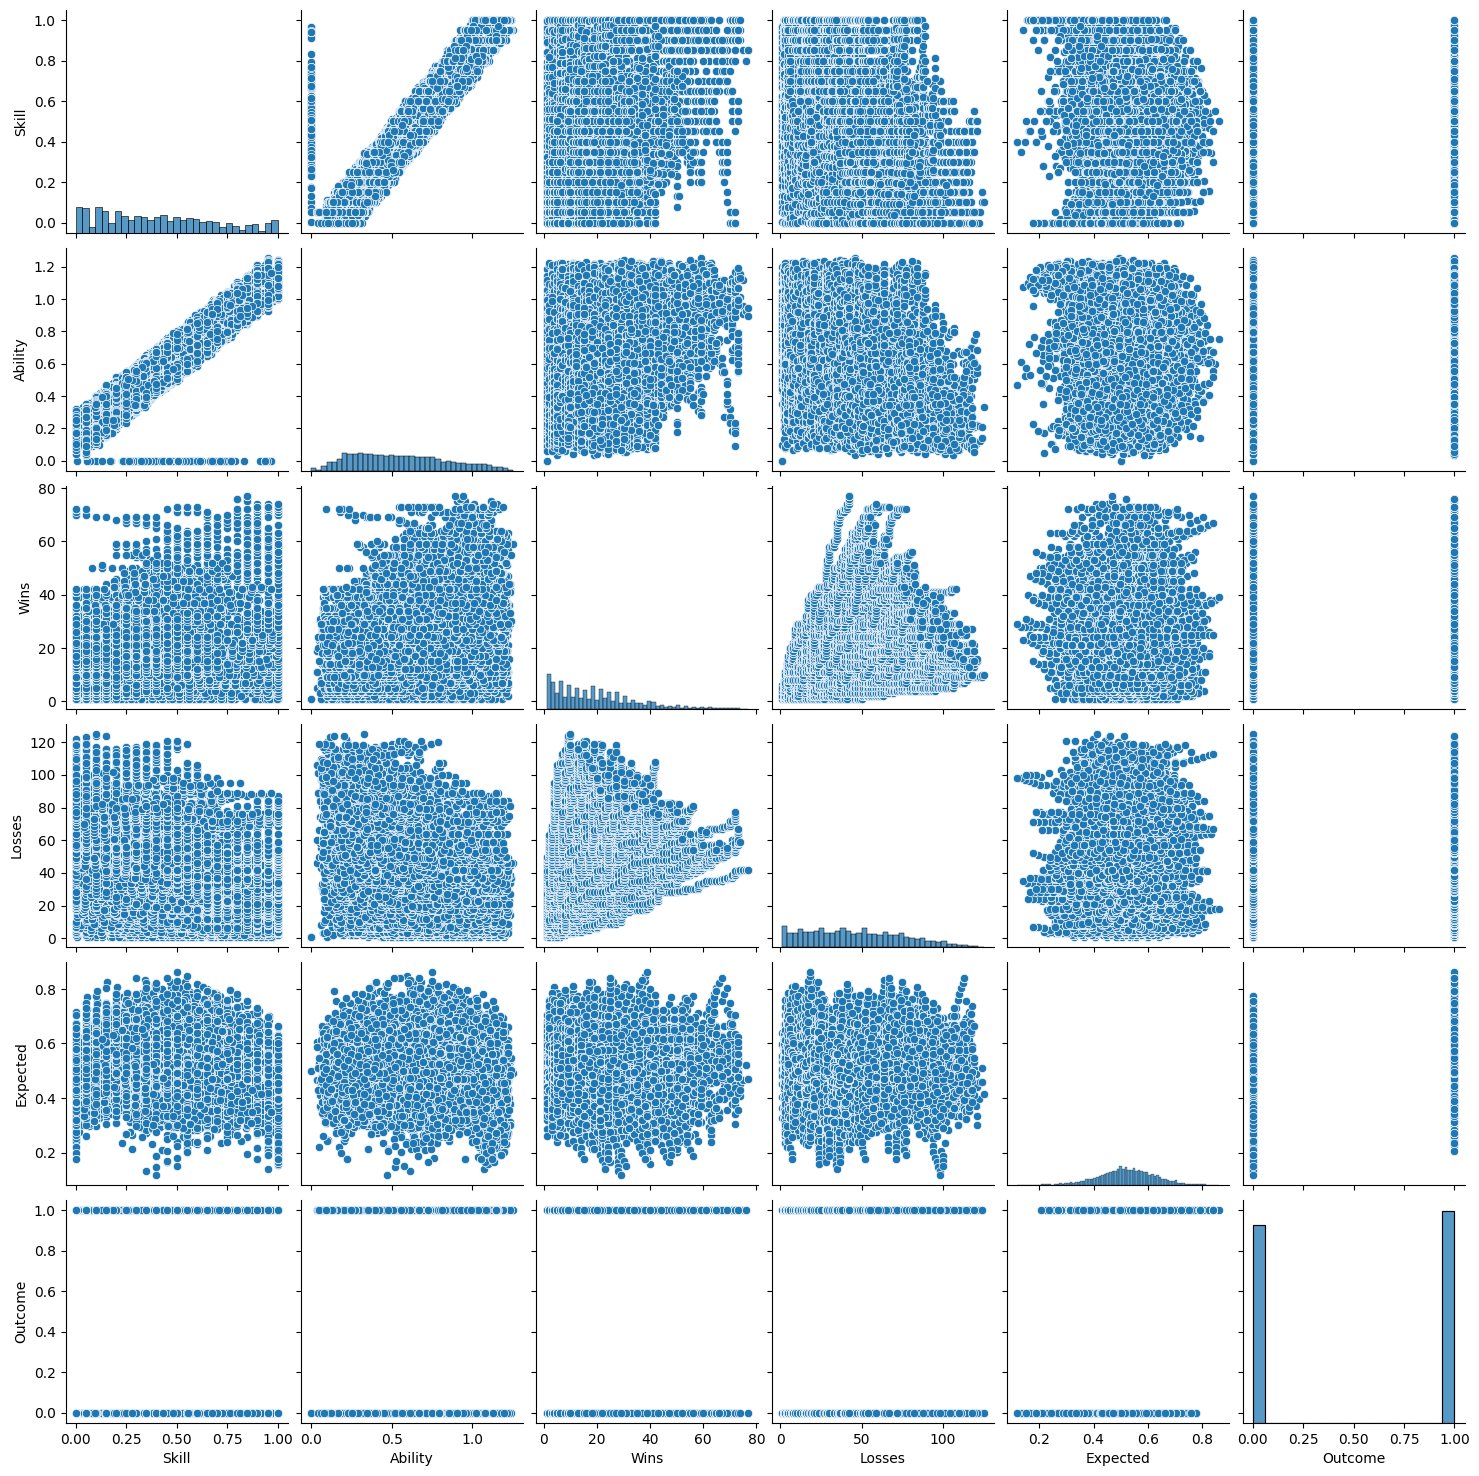

In [7]:
sns.pairplot(data[['Skill', 'Ability', 'Wins', 'Losses', 'Expected', 'Outcome']])
plt.show()

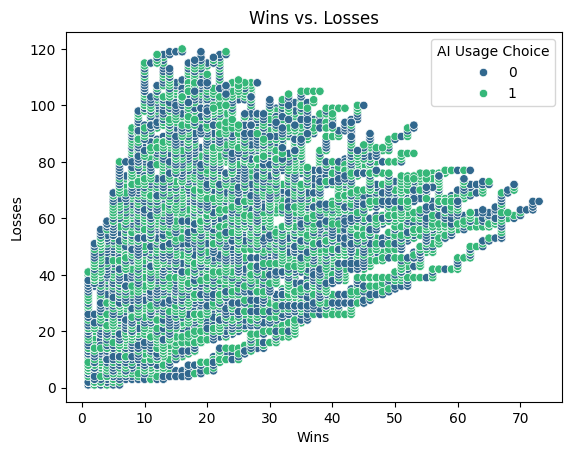

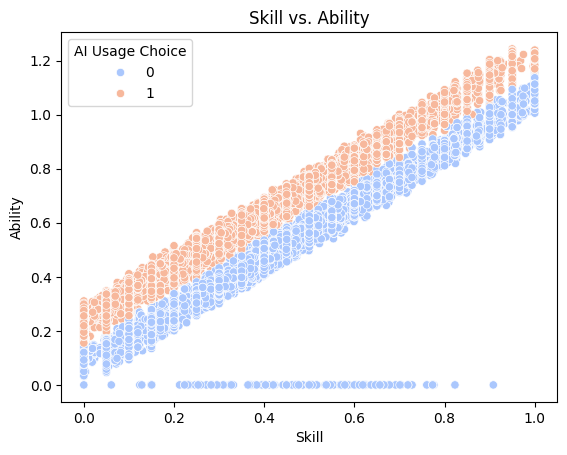

In [20]:

sns.scatterplot(data=data, x='Wins', y='Losses', hue='AI Usage Choice', palette='viridis')
plt.title('Wins vs. Losses')
plt.show()

# Scatter plot for Skill vs Ability at the final step (Step 20)
sns.scatterplot(data=data, x='Skill', y='Ability', hue='AI Usage Choice', palette='coolwarm')
plt.title('Skill vs. Ability')
plt.show()


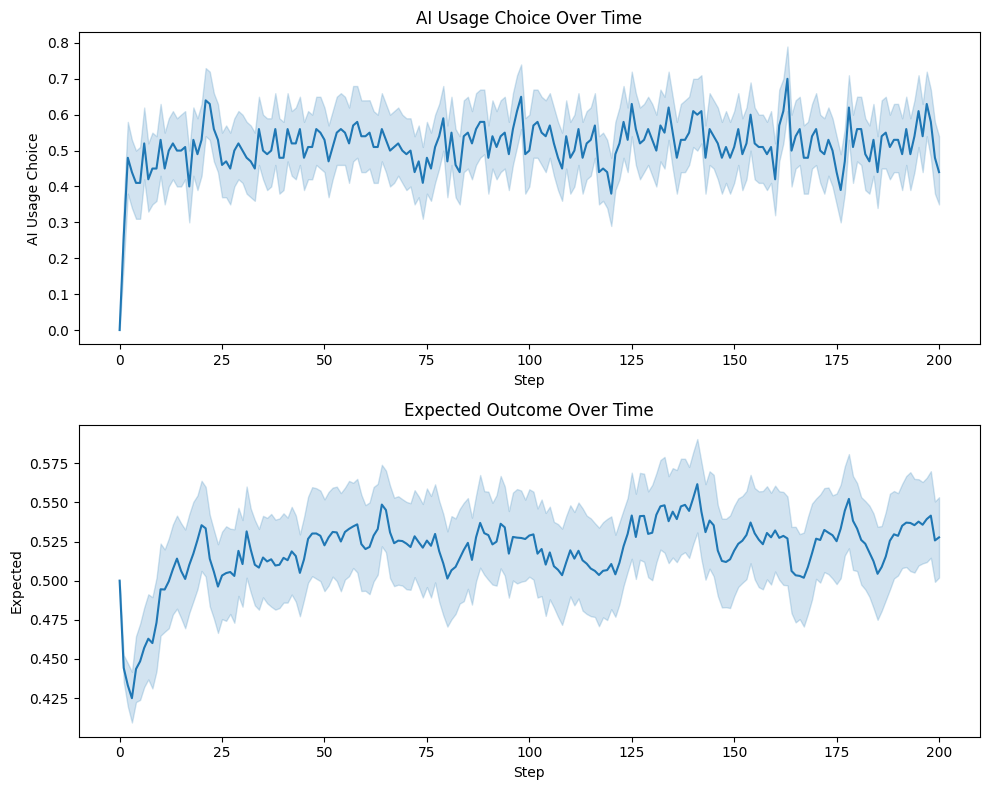

In [17]:

# Line plot for AI Usage Choice and Expected Outcome over time
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot AI Usage Choice
sns.lineplot(data=data, x="Step", y="AI Usage Choice", ax=axes[0])
axes[0].set_title('AI Usage Choice Over Time')

# Plot Expected Outcome
sns.lineplot(data=data, x="Step", y="Expected", ax=axes[1])
axes[1].set_title('Expected Outcome Over Time')

plt.tight_layout()
plt.show()